---
title: "Bayesian Optimization with TabPFN Extensions"
description: "Use TabPFN as a Bayesian optimization surrogate via tabpfn-extensions and compare it against random search on Rosenbrock-4."
cookbookTags:
  - extension
  - optimization
authors:
  - name: Klemens Flöge
    linkedin: https://www.linkedin.com/in/klemens-fl%C3%B6ge/
  - name: Tuana Çelik
    linkedin: https://www.linkedin.com/in/tuanacelik/
    twitter: https://x.com/tuanacelik
---

*Use TabPFN as the surrogate model inside a Bayesian optimization loop.*

This cookbook turns the `tabpfn-extensions` Bayesian optimization example into a step-by-step notebook. We optimize the 4D Rosenbrock benchmark, compare TabPFN-driven search against random search under the same evaluation budget, and show how `propose_next_point()` uses the predictive distribution from TabPFN to compute Expected Improvement (EI).

A single run tells you very little — the starting design alone can decide the outcome. So we repeat the whole experiment **5 times** with different random inits and report the mean with a min–max band.

Relevant resources:

- [`tabpfn-extensions` repository](https://github.com/PriorLabs/tabpfn-extensions)
- [Bayesian optimization example script in `tabpfn-extensions`](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/bayesian_optimization/bayesian_optimization.py)
- [`PFNs4BO` paper / reference implementation](https://github.com/automl/PFNs4BO)
- [TabPFN repo](https://github.com/PriorLabs/TabPFN)


## Setup

*Install the full TabPFN package plus the Bayesian optimization extras from `tabpfn-extensions`.*

This example uses the local PyTorch-backed TabPFN implementation because the optimizer refines candidates with gradients (`differentiable_input=True`).

In [1]:
%pip install -q -U "tabpfn-extensions[bayesian-optimization]" "tabpfn>=8.1.0" "tqdm>=4.63.0,<=4.67.3" matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 732.3/732.3 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 155.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 131.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.4/69.4 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.6/103.6 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 497.5/497.5 kB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not 

*TabPFN as the surrogate, BoTorch for the benchmark objective, and Matplotlib for a quick comparison plot.*

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from botorch.test_functions import Rosenbrock
from tqdm.auto import trange

from tabpfn import TabPFNRegressor
from tabpfn_extensions.bayesian_optimization import propose_next_point


## The Optimization Problem

Rosenbrock-4 is a four-dimensional benchmark with a narrow, curved valley: easy to fall into, hard to walk along. Its optimum is `0.0` at `(1, 1, 1, 1)`, and random search burns most of its budget far outside the valley.

The TabPFN surrogate predicts a **full bar distribution** over the objective value. `propose_next_point()` uses that predictive distribution to compute Expected Improvement, then refines the most promising candidates with gradient ascent on the acquisition function itself.

Two details worth calling out:

- `negate=True` turns the minimization benchmark into a maximization problem, which is what EI expects; `optimal_value` follows the sign.
- The optimizer searches the unit cube `[0, 1]^4`, but Rosenbrock lives on `[-5, 10]^4`, so every candidate is mapped onto the problem's own bounds before evaluation.


In [17]:
N_INIT = 10
N_BO_STEPS = 25
N_SEEDS = 5
N_CANDIDATES = 512
TOP_K = 4
N_REFINE_STEPS = 8
REFINE_LR = 0.05
GAP_FLOOR = 1e-3  # the log axis needs a positive floor

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

# EI maximizes the objective, so we negate Rosenbrock to turn its optimum into a maximum.
objective = Rosenbrock(dim=4, negate=True).to(DEVICE)
LO, HI = objective.bounds[0], objective.bounds[1]
# `optimal_value` comes back as -0.0 after negation; `+ 0.0` normalises the sign.
print(f"Objective optimum: {objective.optimal_value + 0.0:.4f} on {LO.tolist()}..{HI.tolist()}")


def evaluate(unit_x: torch.Tensor) -> torch.Tensor:
    """Evaluate the benchmark on points given in the unit cube."""
    return objective(LO + unit_x * (HI - LO))


Device: cuda
Objective optimum: 0.0000 on [-5.0, -5.0, -5.0, -5.0]..[10.0, 10.0, 10.0, 10.0]


## Build the TabPFN Surrogate

*The critical switch is `differentiable_input=True`.*

That flag keeps gradients flowing from the acquisition value back into the candidate coordinates during refinement. We use a single estimator to stay close to the upstream example and keep runtime short on CPU.

Each repeat gets its own surrogate, seeded with that repeat's index, so the runs are independent.


In [18]:
def make_surrogate(seed: int) -> TabPFNRegressor:
    return TabPFNRegressor(
        n_estimators=1,
        device=DEVICE,
        random_state=seed,
        inference_precision=torch.float32,
        differentiable_input=True,
    )


## Run Bayesian Optimization

*Seed with random points, then let TabPFN propose the next evaluation point.*

Each iteration fits TabPFN on all observed evaluations so far, screens a random candidate pool with Expected Improvement, and refines the top candidates by gradient ascent before returning the next point to evaluate.

We run that loop `N_SEEDS = 5` times. Within a repeat, both methods start from the **same** `N_INIT` random evaluations, so the two curves can only diverge once the acquisition function takes over.


In [19]:
import os
os.environ["TABPFN_TOKEN"] = "tabpfn_sk__83CFTwlqfDvE6iNUcSlW4v-Aydpl55PJ7-96sacv9s"

In [20]:
def run_bo(init_x: torch.Tensor, init_y: torch.Tensor, seed: int) -> torch.Tensor:
    """Run the loop from a fixed random init and return every observed y."""
    reg = make_surrogate(seed)
    train_x, train_y = init_x.clone(), init_y.clone()
    for _ in trange(N_BO_STEPS, desc=f"repeat {seed}", leave=False):
        next_x = propose_next_point(
            reg,
            train_x,
            train_y,
            n_candidates=N_CANDIDATES,
            top_k=TOP_K,
            n_refine_steps=N_REFINE_STEPS,
            refine_lr=REFINE_LR,
        )
        train_x = torch.cat([train_x, next_x.unsqueeze(0)])
        train_y = torch.cat([train_y, evaluate(next_x.unsqueeze(0))])
    return train_y


def gap_to_optimum(y: torch.Tensor) -> np.ndarray:
    """Best-so-far distance to the known optimum — lower is better."""
    best = np.maximum.accumulate(y.detach().cpu().numpy())
    return np.maximum(objective.optimal_value - best, GAP_FLOOR)


bo_gaps, random_gaps = [], []

for seed in range(N_SEEDS):
    # One shared init per repeat: both methods see the same starting evaluations.
    torch.manual_seed(seed)
    init_x = torch.rand(N_INIT, objective.dim, device=DEVICE)
    init_y = evaluate(init_x)

    torch.manual_seed(1000 + seed)
    bo_y = run_bo(init_x, init_y, seed)

    torch.manual_seed(1000 + seed)
    random_y = torch.cat([init_y, evaluate(torch.rand(N_BO_STEPS, objective.dim, device=DEVICE))])

    bo_gaps.append(gap_to_optimum(bo_y))
    random_gaps.append(gap_to_optimum(random_y))
    print(
        f"repeat {seed}: TabPFN gap {bo_gaps[-1][-1]:9.4g} | "
        f"random search gap {random_gaps[-1][-1]:9.4g}"
    )

bo_gap = np.array(bo_gaps)          # (N_SEEDS, N_INIT + N_BO_STEPS)
random_gap = np.array(random_gaps)


repeat 0:   0%|          | 0/25 [00:00<?, ?it/s]

repeat 0: TabPFN gap     928.7 | random search gap      9027


repeat 1:   0%|          | 0/25 [00:00<?, ?it/s]

repeat 1: TabPFN gap     142.5 | random search gap      2804


repeat 2:   0%|          | 0/25 [00:00<?, ?it/s]

repeat 2: TabPFN gap     107.6 | random search gap      5506


repeat 3:   0%|          | 0/25 [00:00<?, ?it/s]

repeat 3: TabPFN gap     169.8 | random search gap      4762


repeat 4:   0%|          | 0/25 [00:00<?, ?it/s]

repeat 4: TabPFN gap      2405 | random search gap     915.8


In [ ]:
#   Copyright (c) 2026. vencortex® – DeOS | Decision Optimization System. DeOSAlpha Library. All rights reserved.

from __future__ import annotations
#   Copyright (c) 2026. vencortex® – DeOS | Decision Optimization System. DeOSAlpha Library. All rights reserved.

from __future__ import annotations

import matplotlib.pyplot as plt
import numpy as np
import optuna
from botorch.test_functions import Rosenbrock
from sklearn.datasets import make_regression

from deos_alpha.capabilities.causal_prediction.causal_predictor.models.foundation_models.icl_max.models import (
    DeOSAlphaTabularFoundationICLMaxRegressor,
)
import matplotlib.pyplot as plt
import numpy as np
import torch
from botorch.test_functions import Rosenbrock
from optuna.samplers import CmaEsSampler, TPESampler

from deos_alpha.capabilities.causal_prediction.causal_predictor.models.foundation_models.icl_max.models import (
    DeOSAlphaTabularFoundationICLMaxRegressor,
)
from deos_alpha.capabilities.causal_prediction.imputation.model import (
    DeOSAlphaTabularICLImputationPredictor,
)
from deos_alpha.capabilities.optimization.policy_optimization.models.context_policy_optimizer.models.icl.base import (
    CausalICLActiveLearnerModelType,
)
from deos_alpha.capabilities.optimization.policy_optimization.models.context_policy_optimizer.models.icl.predictor import (
    DeOSAlphaCausalICLSampler,
)

# Benchmark Constants
N_INIT = 10
N_BO_STEPS = 25
N_SEEDS = 5
N_CANDIDATES = 512
TOP_K = 4
N_REFINE_STEPS = 8
REFINE_RADIUS = 0.05  # trust-region box size as a fraction of each dim's span
GAP_FLOOR = 1e-3  # positive floor for log scale

DEVICE = "mps"
print(f"Device: {DEVICE}")

# EI maximizes objective, so we negate Rosenbrock to turn optimum into a maximum.
objective = Rosenbrock(dim=4, negate=True).to(DEVICE)
LO, HI = objective.bounds[0], objective.bounds[1]

print(
    f"Objective optimum: {objective.optimal_value + 0.0:.4f} on"
    f" {LO.tolist()}..{HI.tolist()}"
)


def evaluate(unit_x: torch.Tensor) -> torch.Tensor:
    """Evaluate the benchmark on points given in the unit cube."""
    return objective(LO + unit_x * (HI - LO))


def run_optuna(
    sampler_cls,
    init_x: torch.Tensor,
    init_y: torch.Tensor,
    seed: int,
    **sampler_kwargs,
) -> torch.Tensor:
    """Run an Optuna study starting from shared init points and return all observed y values."""
    sampler = sampler_cls(seed=seed, **sampler_kwargs)
    study = optuna.create_study(direction="maximize", sampler=sampler)

    dim = objective.dim
    distributions = {
        f"x{i}": optuna.distributions.FloatDistribution(0.0, 1.0)
        for i in range(dim)
    }

    # 1. Inject shared initial evaluations
    for x_val, y_val in zip(init_x, init_y):
        params = {f"x{i}": float(x_val[i].cpu()) for i in range(dim)}
        trial = optuna.trial.create_trial(
            params=params,
            distributions=distributions,
            value=float(y_val.cpu()),
        )
        study.add_trial(trial)

    # 2. Define objective for remaining BO steps
    def optuna_objective(trial):
        x_list = [trial.suggest_float(f"x{i}", 0.0, 1.0) for i in range(dim)]
        unit_x = (
            torch.tensor(x_list, dtype=torch.float32, device=DEVICE)
            .unsqueeze(0)
        )
        y_val = evaluate(unit_x)
        return float(y_val.cpu())

    # 3. Optimize
    study.optimize(optuna_objective, n_trials=N_BO_STEPS)

    # 4. Collect all trial values in order
    all_y = [t.value for t in study.trials]
    return torch.tensor(all_y, dtype=torch.float32, device=DEVICE)


def gap_to_optimum(y: torch.Tensor) -> np.ndarray:
    """Best-so-far distance to the known optimum — lower is better."""
    best = np.maximum.accumulate(y.detach().cpu().numpy())
    return np.maximum(objective.optimal_value - best, GAP_FLOOR)


# =============================================================================
# Benchmark Execution Loop
# =============================================================================
deos_std_gaps = []
deos_max_gaps = []
deos_impute_gaps = []
tpe_gaps = []
cma_gaps = []
random_gaps = []

for seed in range(N_SEEDS):
    # Shared initial evaluations for fair comparison across all algorithms
    torch.manual_seed(seed)
    init_x = torch.rand(N_INIT, objective.dim, device=DEVICE)
    init_y = evaluate(init_x)

    # Common sampler kwargs
    base_deos_kwargs = dict(
        n_startup_trials=N_INIT,
        num_candidates=N_CANDIDATES,
        top_k_anchors=TOP_K,
        n_refine_steps=N_REFINE_STEPS,
        refine_radius=REFINE_RADIUS,
        model_type=CausalICLActiveLearnerModelType.EXPECTED_IMPROVEMENT,
    )

    # 1a. DeOS Standard ICL Regressor
    torch.manual_seed(1000 + seed)

    # 2. Optuna TPE
    tpe_y = run_optuna(TPESampler, init_x, init_y, seed=1000 + seed)

    # 3. Optuna CMA-ES
    cma_y = run_optuna(CmaEsSampler, init_x, init_y, seed=1000 + seed)

    # 4. Random search
    torch.manual_seed(1000 + seed)
    random_y = torch.cat(
        [init_y, evaluate(torch.rand(N_BO_STEPS, objective.dim, device=DEVICE))]
    )

    tpe_gaps.append(gap_to_optimum(tpe_y))
    cma_gaps.append(gap_to_optimum(cma_y))
    random_gaps.append(gap_to_optimum(random_y))

    print(
        f"repeat {seed:2d} | "
        f"DeOS Std: {deos_std_gaps[-1][-1]:7.4g} | "
        f"TPE: {tpe_gaps[-1][-1]:7.4g} | "
        f"CMA-ES: {cma_gaps[-1][-1]:7.4g} | "
        f"Random: {random_gaps[-1][-1]:7.4g}"
    )

deos_std_gap = np.array(bo_gap)
tpe_gap = np.array(tpe_gaps)
cma_gap = np.array(cma_gaps)
random_gap = np.array(random_gaps)

print("=" * 95)
for name, gaps in [
    ("DeOS Standard ICL", bo_gap),
    ("Optuna TPE", tpe_gap),
    ("Optuna CMA-ES", cma_gap),
    ("Random search", random_gap),
]:
    final = gaps[:, -1]
    print(
        f"{name:<24} final gap over {N_SEEDS} repeats: "
        f"mean {final.mean():9.4g} | median {np.median(final):9.4g} | best {final.min():9.4g}"
    )
print("=" * 95)


# =============================================================================
# Visualizations
# =============================================================================
evals = np.arange(1, deos_std_gap.shape[1] + 1)

fig, ax = plt.subplots(figsize=(9.5, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.set_yscale("log")

methods = [
    (deos_std_gap, "DeOS Standard ICL", "#e63946"),
    (tpe_gap, "Optuna TPE", "#d6602a"),
    (cma_gap, "Optuna CMA-ES", "#8b2ad6"),
    (random_gap, "Random search", "#6c757d"),
]

for curves, label, color in methods:
    ax.fill_between(
        evals,
        curves.min(0),
        curves.max(0),
        color=color,
        alpha=0.08,
        lw=0,
    )
    ax.plot(evals, curves.mean(0), color=color, lw=2, label=label)

ax.axvline(N_INIT, color="#898781", lw=1, ls=(0, (2, 3)))

ax.set_title(
    "Rosenbrock-16 Benchmark (Comparison of DeOS ICL Backends)",
    fontsize=11,
    color="#0b0b0b",
    loc="left",
    fontweight="bold",
    pad=8,
)
ax.grid(visible=True, axis="y", color="#e1e0d9", linewidth=0.6)
ax.set_axisbelow(True)

for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c3c2b7")

ax.tick_params(colors="#898781", labelsize=8, length=3)
ax.set_xlim(1, N_INIT + N_BO_STEPS)
ax.set_xlabel("evaluation", fontsize=9, color="#52514e")
ax.set_ylabel("gap to optimum (log)", fontsize=9, color="#52514e")
ax.legend(frameon=False, fontsize=9.0, labelcolor="#0b0b0b")

fig.suptitle(
    f"Best-so-far gap to optimum — mean over {N_SEEDS} repeats, bands are min-max"
    "   (dotted line: end of shared random init)",
    fontsize=11,
    color="#0b0b0b",
    x=0.02,
    ha="left",
    y=1.02,
)
fig.tight_layout()
plt.show()

## Compare Against Random Search

*Same objective, same budget, same starting points — only the choice of the next point differs.*

Rosenbrock values span several orders of magnitude, so we report the **gap to the optimum** (`optimum - best so far`) rather than the raw objective. Lower is better.


In [21]:
for name, gaps in [("TabPFN", bo_gap), ("Random search", random_gap)]:
    final = gaps[:, -1]
    print(
        f"{name:<14} final gap over {N_SEEDS} repeats: "
        f"mean {final.mean():9.4g} | median {np.median(final):9.4g} | best {final.min():9.4g}"
    )


TabPFN         final gap over 5 repeats: mean     750.8 | median     169.8 | best     107.6
Random search  final gap over 5 repeats: mean      4603 | median      4762 | best     915.8


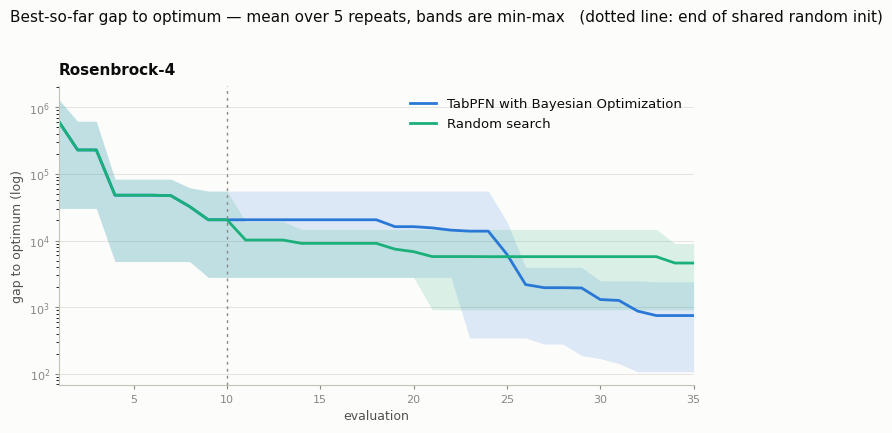

In [22]:
evals = np.arange(1, bo_gap.shape[1] + 1)

fig, ax = plt.subplots(figsize=(7.2, 4.2), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")
ax.set_yscale("log")

# Mean over repeats, band spans min-max across them.
for curves, label, color in [
    (bo_gap, "TabPFN with Bayesian Optimization", "#2a78d6"),
    (random_gap, "Random search", "#1baf7a"),
]:
    ax.fill_between(evals, curves.min(0), curves.max(0), color=color, alpha=0.15, lw=0)
    ax.plot(evals, curves.mean(0), color=color, lw=2, label=label)
ax.axvline(N_INIT, color="#898781", lw=1, ls=(0, (2, 3)))

ax.set_title("Rosenbrock-4", fontsize=11, color="#0b0b0b", loc="left", fontweight="bold", pad=8)
ax.grid(visible=True, axis="y", color="#e1e0d9", linewidth=0.6)
ax.set_axisbelow(True)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
for side in ("left", "bottom"):
    ax.spines[side].set_color("#c3c2b7")
ax.tick_params(colors="#898781", labelsize=8, length=3)
ax.set_xlim(1, N_INIT + N_BO_STEPS)
ax.set_xlabel("evaluation", fontsize=9, color="#52514e")
ax.set_ylabel("gap to optimum (log)", fontsize=9, color="#52514e")
ax.legend(frameon=False, fontsize=9.5, labelcolor="#0b0b0b")

fig.suptitle(
    f"Best-so-far gap to optimum — mean over {N_SEEDS} repeats, bands are min-max"
    "   (dotted line: end of shared random init)",
    fontsize=11,
    color="#0b0b0b",
    x=0.02,
    ha="left",
    y=1.02,
)
fig.tight_layout()
plt.show()


## Takeaways

- `tabpfn-extensions` already provides the Bayesian Optimization loop primitive: `propose_next_point()`
- On Rosenbrock-4, TabPFN with Bayesian Optimization should close the gap to the optimum faster than random search under the same evaluation budget.
- For more background, start with the upstream [example](https://github.com/PriorLabs/tabpfn-extensions/blob/main/examples/bayesian_optimization/bayesian_optimization.py) and the [`tabpfn-extensions` repo](https://github.com/PriorLabs/tabpfn-extensions).
